Dataset:
 StudentID  X  Y
       S1  1  2
       S2  2  3
       S3  3  4 

Iter          m         c    Cost J(m,c)       dJ/dm       dJ/dc
1        0.0000    0.0000         9.6667    -13.3333     -6.0000
2        1.3333    0.6000         0.1452      1.5111      0.5333
After 2 iterations -> m = 1.1822, c = 0.5467, Cost = 0.0300


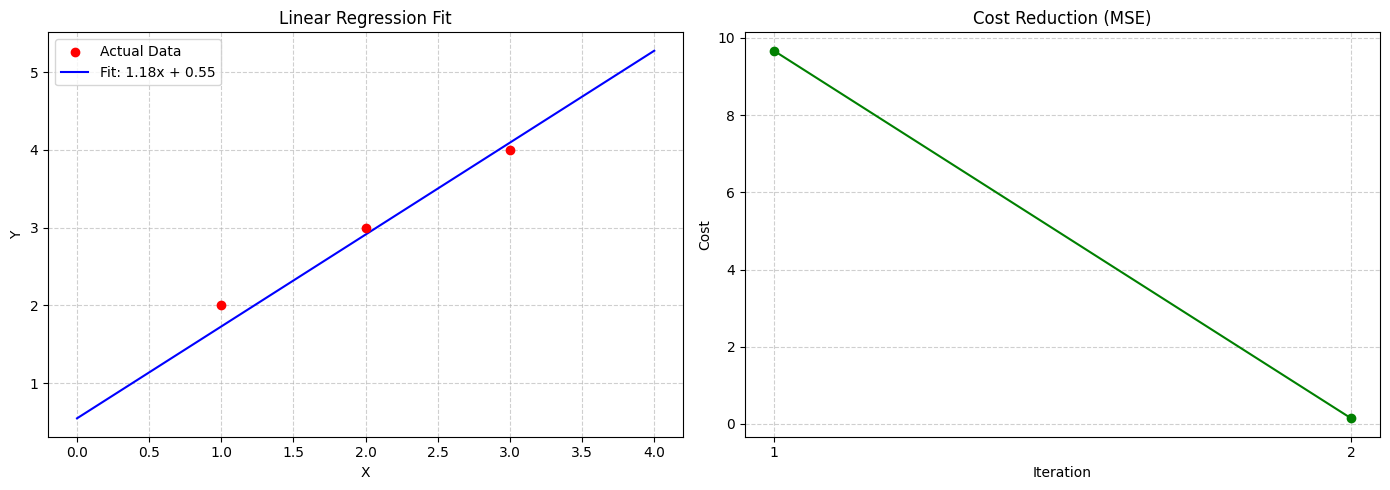

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_dataset():
    data = pd.DataFrame({
        "StudentID": ["S1", "S2", "S3"],
        "X": [1, 2, 3],
        "Y": [2, 3, 4]
    })
    return data

def initialize_parameters():
    return 0.0, 0.0

def predict(X, m, c):
    return m * X + c

def compute_cost(y_true, y_pred):
    n = len(y_true)
    return np.sum((y_pred - y_true) ** 2) / n

def compute_gradients(X, y_true, y_pred):
    n = len(X)
    error = y_pred - y_true
    dm = 2 * np.sum(error * X) / n
    dc = 2 * np.sum(error) / n
    return dm, dc

def update_parameters(m, c, dm, dc, alpha):
    m_new = m - alpha * dm
    c_new = c - alpha * dc
    return m_new, c_new

def gradient_descent(X, y_true, alpha=0.1, iterations=2):
    m, c = initialize_parameters()
    history = []
    for i in range(1, iterations + 1):
        y_pred = predict(X, m, c)
        cost = compute_cost(y_true, y_pred)
        dm, dc = compute_gradients(X, y_true, y_pred)
        history.append({
            "iteration": i,
            "m": m,
            "c": c,
            "cost": cost,
            "dm": dm,
            "dc": dc,
            "y_pred": y_pred.copy()
        })
        m, c = update_parameters(m, c, dm, dc, alpha)
    final_pred = predict(X, m, c)
    final_cost = compute_cost(y_true, final_pred)
    return m, c, final_cost, history

def print_report(history, final_m, final_c, final_cost):
    print(f"{'Iter':<5}{'m':>10}{'c':>10}{'Cost J(m,c)':>15}{'dJ/dm':>12}{'dJ/dc':>12}")
    for h in history:
        print(f"{h['iteration']:<5}{h['m']:>10.4f}{h['c']:>10.4f}"
              f"{h['cost']:>15.4f}{h['dm']:>12.4f}{h['dc']:>12.4f}")
    print(f"After {len(history)} iterations -> m = {final_m:.4f}, "
          f"c = {final_c:.4f}, Cost = {final_cost:.4f}")

def main():
    data = load_dataset()
    print("Dataset:\n", data.to_string(index=False), "\n")
    X_val = data["X"].values.astype(float)
    Y_val = data["Y"].values.astype(float)
    ALPHA = 0.1
    ITERATIONS = 2

    final_m, final_c, final_cost, history = gradient_descent(
        X_val, Y_val, alpha=ALPHA, iterations=ITERATIONS
    )

    print_report(history, final_m, final_c, final_cost)

    iters = [h['iteration'] for h in history]
    costs = [h['cost'] for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.scatter(X_val, Y_val, color='red', label='Actual Data', zorder=3)
    X_range = np.linspace(X_val.min()-1, X_val.max()+1, 100)
    ax1.plot(X_range, final_m * X_range + final_c, color='blue', label=f'Fit: {final_m:.2f}x + {final_c:.2f}')
    ax1.set_title('Linear Regression Fit')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(iters, costs, marker='o', linestyle='-', color='green')
    ax2.set_title('Cost Reduction (MSE)')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Cost')
    ax2.set_xticks(iters)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()